Graph Visualisation Notebook

Importing (35 s)

In [3]:
df_path = '/Users/nubia/Desktop/Thesis_2.0/dataset/df.joblib'
merged_df_path = '/Users/nubia/Desktop/Thesis_2.0/dataset/merged_df.joblib'

import joblib 
from supportive_functions import * 

df = joblib.load(df_path)
merged_df = joblib.load(merged_df_path)


#Some functions that I use multiple times

def transformation_2D(x, y, z):
    r = []
    for i in range(len(x)):
        r.append(np.sqrt(x[i]**2 + y[i]**2))
    return r, z

In [12]:
%matplotlib inline

Visual graph of trap with some landings (3D and 2D). 

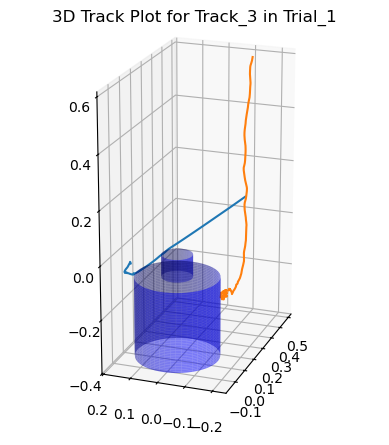

In [ ]:
from matplotlib import pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extract the data for Track_3
x = df['Trial_1'].loc['Track_3', 'x']
y = df['Trial_1'].loc['Track_3', 'y']
z = df['Trial_1'].loc['Track_3', 'z']

x2 = merged_df['Trial_1'].loc['Merged_Chain_3', 'x']
y2 = merged_df['Trial_1'].loc['Merged_Chain_3', 'y']
z2 = merged_df['Trial_1'].loc['Merged_Chain_3', 'z']

# Plot the 3D line
ax.plot(x, y, z)
ax.plot(x2, y2, z2)

ax.set_title('3D Track Plot for Track_3 in Trial_1')
x_grid_body, y_grid_body, z_grid_body, x_grid_inlet, y_grid_inlet, z_grid_inlet = getTrap()
ax.plot_surface(x_grid_body, y_grid_body, z_grid_body, alpha=0.5, color='b')
ax.plot_surface(x_grid_inlet, y_grid_inlet, z_grid_inlet, alpha=0.5, color='b')
ax.set_aspect('equal', adjustable='box')

ax.view_init(elev=20, azim=200)
plt.show()

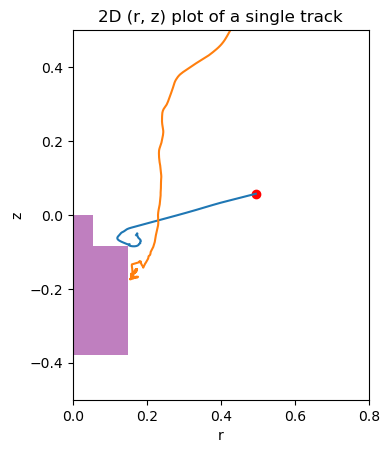

In [ ]:
# Extract the data for Track_3
x = df['Trial_1'].loc['Track_3', 'x']
y = df['Trial_1'].loc['Track_3', 'y']
z = df['Trial_1'].loc['Track_3', 'z']

x2 = merged_df['Trial_1'].loc['Merged_Chain_3', 'x']
y2 = merged_df['Trial_1'].loc['Merged_Chain_3', 'y']
z2 = merged_df['Trial_1'].loc['Merged_Chain_3', 'z']

r, z = transformation_2D(x, y, z)
last_r, last_z = r[-1], z[-1]
r2, z2 = transformation_2D(x2, y2, z2)
last_r2, last_z2 = r2[-1], z2[-1]

plt.plot(r, z)
plt.plot(r2, z2)
plt.scatter(last_r, last_z, color='r', marker='o')
plt.scatter(last_r2, last_z2, color='r', marker='o')

inlet_r, inlet_z, body_r, body_z = getTrap2D()
# Plot trap
plt.fill(inlet_r, inlet_z, color='purple', linewidth = 0, alpha = 0.5)
plt.fill(body_r, body_z, color='purple', linewidth = 0, alpha = 0.5)
plt.xlim(0, 0.8)
plt.ylim(-0.5, 0.5)
plt.xlabel('r')
plt.ylabel('z')
plt.title('2D (r, z) plot of a single track')
plt.gca().set_aspect('equal', adjustable='box')  # Ensure aspect ratio is square
plt.show()

Heatmaps visualisations

1. Heatmap landing points
    1. Function landing_points 
    2. plotting heatmap 

In [4]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

def landing_points(start_trial_num = 1, end_trial_num = 65): 
    last_r, last_z = [], []
    for trial_num in range(start_trial_num, end_trial_num):
        for track_name, track_data in df[f'Trial_{trial_num}'].iterrows():
            x = track_data['x']
            y = track_data['y']
            z = track_data['z']
            if landing_area(x, y, z): 
                r, z = transformation_2D(x, y, z)
                last_r.append(r[-1])
                last_z.append(r[-1])
    return last_r, last_z


r_list, z_list = landing_points(1, 2)
print(len(r_list))


colors = [(1, 1, 1), (1, 0.8, 0), (1, 0, 0), (0.5, 0, 0)]  # White -> Yellow -> Red -> Dark Red
custom_cmap = LinearSegmentedColormap.from_list("custom_red_hot", colors)
plt.hist2d(r_list, z_list, bins=[10, 40], cmap=custom_cmap)
plt.colorbar(label='Density')
plt.xlabel('r coordinate')
plt.ylabel('z coordinate')
plt.title('Density Heatmap of Landing Coordinates Dataset')
# plot trap
inlet_r, inlet_z, body_r, body_z = getTrap2D()
plt.fill(inlet_r, inlet_z, color='purple', edgecolor = 'none', alpha = 0.5)
plt.fill(body_r, body_z, color='purple', edgecolor = 'none', alpha = 0.5)
plt.xlim(0, 0.3)
plt.ylim(-0.45, 0.1)
plt.gca().set_aspect('equal', adjustable='box')  # Ensure aspect ratio is square
plt.show()


TypeError: '<' not supported between instances of 'float' and 'tuple'